## 1. Importing the Data

In [64]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
# Load Excel file
df = pd.read_csv("D:\Data to deal with\Fashion Retail Sales\Fashion_Retail_Sales.csv")

In [66]:
df = pd.DataFrame(df)

## 2. Exploratory Data Analysis

In [67]:
# Check data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3400 non-null   int64  
 1   Item Purchased         3400 non-null   object 
 2   Purchase Amount (USD)  2750 non-null   float64
 3   Date Purchase          3400 non-null   object 
 4   Review Rating          3076 non-null   float64
 5   Payment Method         3400 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 159.5+ KB


In [68]:
# Summary statistics
df[['Purchase Amount (USD)','Review Rating']].describe()

,Purchase Amount (USD),Review Rating
count,2750.000000,3076.000000
mean,156.709818,2.999057
std,419.536669,1.156505
min,10.000000,1.000000
25%,57.000000,2.000000
50%,110.000000,3.000000
75%,155.750000,4.000000
max,4932.000000,5.000000


In [69]:
df.sample(10)

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
1846,4020,Raincoat,150.0,13-02-2023,2.4,Cash
979,4042,Blouse,137.0,02-05-2023,1.9,Credit Card
2335,3980,Cardigan,22.0,24-02-2023,5.0,Cash
2610,4026,Flip-Flops,108.0,22-11-2022,3.3,Cash
2570,3967,Sweater,100.0,06-07-2023,1.1,Cash
613,4040,Vest,68.0,05-03-2023,2.3,Credit Card
90,4054,Handbag,12.0,29-12-2022,2.6,Credit Card
1800,3995,Jacket,16.0,15-04-2023,2.5,Credit Card
1360,3963,Hat,141.0,05-09-2023,4.9,Credit Card
2412,4103,Cardigan,NaN,07-01-2023,1.1,Credit Card


In [70]:
# Check duplicated Values
df.duplicated().sum()

0

In [71]:
# Check missing values
df.isnull().sum()

Customer Reference ID      0
Item Purchased             0
Purchase Amount (USD)    650
Date Purchase              0
Review Rating            324
Payment Method             0
dtype: int64

## 3. Data Cleaning

<AxesSubplot:xlabel='Purchase Amount (USD)', ylabel='Count'>

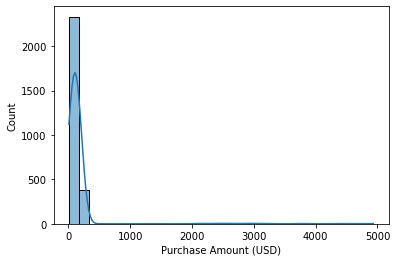

In [72]:
#Data Dist
sns.histplot(data = df['Purchase Amount (USD)'] ,kde = True ,bins = 30)

In [73]:
# Fill missing with median
df['Purchase Amount (USD)'].fillna(df['Purchase Amount (USD)'].median() ,inplace = True)

<AxesSubplot:xlabel='Review Rating', ylabel='Count'>

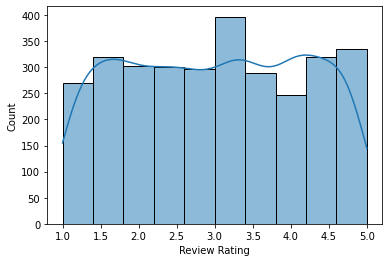

In [74]:
#Data Dist
sns.histplot(data = df['Review Rating'] ,kde = True ,bins = 10)

In [75]:
# Fill missing with mean
df['Review Rating'].fillna(df['Review Rating'].mean() ,inplace = True)

In [76]:
# Round Review Rating
df['Review Rating'] = df['Review Rating'].round(2)

## 4. Conclusions

In [77]:
# Classifies the item based on its rating
# If the rating is 4.0 or higher, it is considered "High Rated Item"
# If the rating is between 2.5 and 3.9, it is considered "Normal Rated Item"
# If the rating is less than or equal to 2.5, it is considered "Low Rated Item"
def Rating_Category(x):
    if x >= 4.0:
        return "High Rated Item"
    elif 2.5 < x < 3.9:
        return "Normal Rated Item"
    else:
        return "Low Rated Item"

In [78]:
#apply the code
df['Item Rate Category'] = df['Review Rating'].apply(Rating_Category)

In [79]:
# Divides 'Purchase Amount (USD)' into 3 quantiles and labels customers accordingly
df['Customer Segment'] = pd.qcut(df['Purchase Amount (USD)'] ,q=3 ,labels=['Low Value Customer','Mid Value Customer','High Value Customer'])

In [80]:
# Counts the number of customers in each segment ('Low Value Customer', 'Mid Value Customer', 'High Value Customer')
df['Customer Segment'].value_counts()

Low Value Customer     1141
Mid Value Customer     1138
High Value Customer    1121
Name: Customer Segment, dtype: int64

In [81]:
#Top Selling Items 
df.groupby('Item Purchased')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

Item Purchased
Tunic            18045.0
Pajamas          14998.0
Jeans            14168.0
Shorts           14132.0
Handbag          14098.0
Boots            13321.0
Gloves           13100.0
Poncho           12852.0
Belt             12794.0
Loafers          12765.0
Slippers         12604.0
Flip-Flops       12409.0
Blouse           12232.0
Sweater          12080.0
Blazer           11855.0
Trench Coat      11312.0
Romper           11221.0
T-shirt          11133.0
Hoodie           11009.0
Pants            10945.0
Swimsuit         10896.0
Onesie           10869.0
Wallet           10802.0
Cardigan         10480.0
Kimono           10450.0
Tank Top         10056.0
Scarf             9945.0
Bowtie            9585.0
Socks             9573.0
Leggings          9517.0
Jacket            9439.0
Skirt             9337.0
Trousers          8438.0
Raincoat          8317.0
Backpack          7928.0
Sneakers          7756.0
Camisole          7676.0
Vest              7620.0
Umbrella          7575.0
Coat      

In [82]:
#Top Rated Items
df.groupby('Item Purchased')['Review Rating'].mean().sort_values(ascending = False).round(2)

Item Purchased
Sun Hat          3.44
Flip-Flops       3.28
Sandals          3.24
Jeans            3.24
Boots            3.20
Scarf            3.19
Skirt            3.18
Jumpsuit         3.17
Wallet           3.17
Tank Top         3.17
Trench Coat      3.16
Handbag          3.15
Coat             3.14
Umbrella         3.12
Romper           3.10
Swimsuit         3.09
Gloves           3.08
Slippers         3.07
Sneakers         3.06
Backpack         3.06
Sweater          3.06
Pants            3.05
Blazer           3.05
Tie              3.04
Cardigan         3.04
Overalls         3.02
Dress            3.02
Belt             3.00
T-shirt          3.00
Raincoat         3.00
Onesie           3.00
Hoodie           2.98
Kimono           2.97
Poncho           2.96
Blouse           2.93
Vest             2.93
Bowtie           2.92
Shorts           2.92
Hat              2.90
Trousers         2.87
Polo Shirt       2.86
Loafers          2.85
Pajamas          2.84
Leggings         2.79
Sunglasses       

In [83]:
df['Customer Segment'].value_counts()

Low Value Customer     1141
Mid Value Customer     1138
High Value Customer    1121
Name: Customer Segment, dtype: int64

## 5. Exploratory Data Analysis

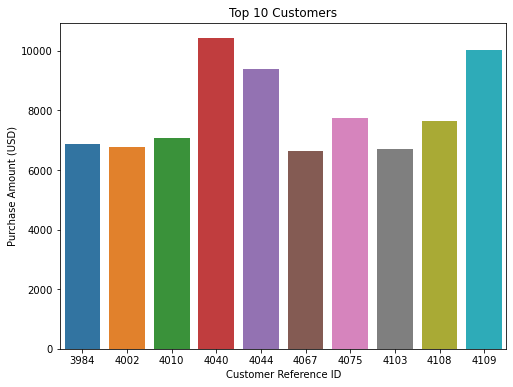

In [84]:
#Top 10 Customers ID's By Purchase Amount
TC = df.groupby('Customer Reference ID')['Purchase Amount (USD)'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(8,6))
sns.barplot(x='Customer Reference ID', y='Purchase Amount (USD)', data=TC)
plt.title('Top 10 Customers')
plt.show()

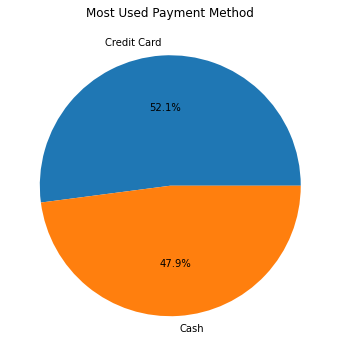

In [85]:
# Pie chart of payment method
plt.figure(figsize=(8,6))
plt.pie(df['Payment Method'].value_counts() ,labels=df['Payment Method'].value_counts().index ,autopct ='%1.1f%%')
plt.title('Most Used Payment Method')
plt.show()


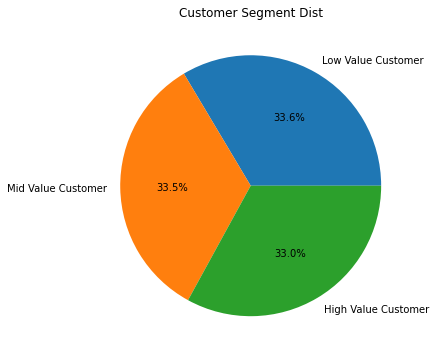

In [86]:
# Pie chart of customer segment
plt.figure(figsize=(8,6))
plt.pie(df['Customer Segment'].value_counts() ,labels=df['Customer Segment'].value_counts().index ,autopct='%1.1f%%')
plt.title('Customer Segment Dist')
plt.show()

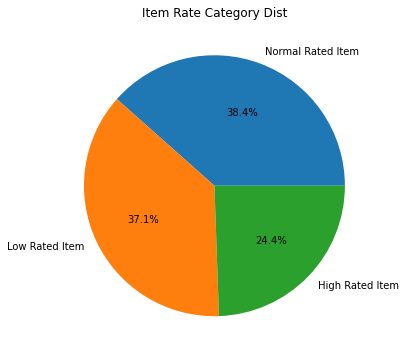

In [87]:
# Pie chart of rating category
plt.figure(figsize=(8,6))
plt.pie(df['Item Rate Category'].value_counts() ,labels=df['Item Rate Category'].value_counts().index ,autopct='%1.1f%%')
plt.title('Item Rate Category Dist')
plt.show()

In [88]:
# Monthly trend of purchases
df.set_index('Date Purchase')['Purchase Amount (USD)'].resample('M').sum().plot(figsize=(20,6))
plt.title("Monthly Purchase Trend")
plt.xlabel("Month")
plt.ylabel("Total Purchase Amount (USD)")
plt.grid(True)
plt.show()


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

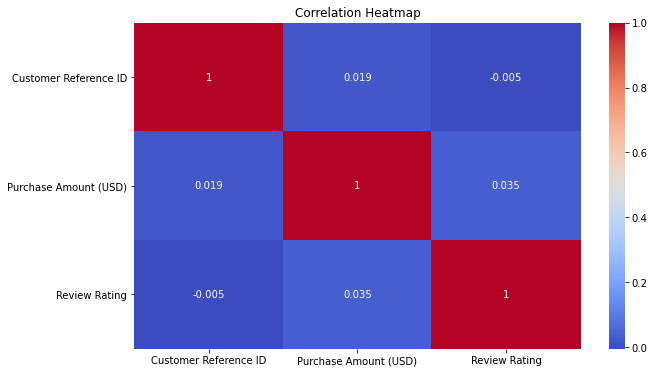

In [89]:
# Correlation heatmap for numeric columns
numeric_df = df.select_dtypes(include='number')  # filter numeric columns
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


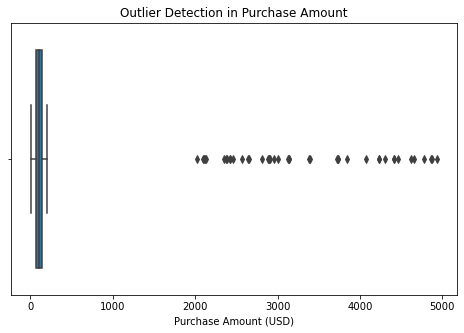

In [90]:
# Boxplot for detecting outliers in Purchase Amount
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Purchase Amount (USD)'])
plt.title("Outlier Detection in Purchase Amount")
plt.show()


# Save The DataFrame

In [94]:
df.to_excel(r'D:\Data Analysis Projects\Project 4 (Fashion Retail)\CSV\data_frame_output.xlsx', index=False)
